In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json 
from matplotlib_venn import venn2

fsize = 20
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [20]:
def load_human_evidence(fn):
    # we only want derived since we're going to compare gene ids
    df = pd.read_json(fn)
    derived_df = df['derived'].apply(pd.Series)
    return derived_df

def load_deg_evidence(fn):
    df = pd.read_json(fn)
    df = df.apply(pd.Series)
    return df

In [21]:
fn_human = "../../data/adipose_Hildreth2021/evidence_human/evidence.json"
fn_deg = "../../data/adipose_Hildreth2021/evidence_deg/evidence.json"

derived_human_ev = load_human_evidence(fn_human)
deg_ev = load_deg_evidence(fn_deg)

deg_ev

,cell_type_label,gene,organism,cell_source,cell_state,gene_id
0,B cell,IGHG3,homo_sapiens,adipose,NaN,ENSG00000211897
1,B cell,IGHG1,homo_sapiens,adipose,NaN,ENSG00000211896
2,B cell,IGLC3,homo_sapiens,adipose,NaN,ENSG00000211679
3,B cell,IGHA1,homo_sapiens,adipose,NaN,ENSG00000211895
4,B cell,IGLC2,homo_sapiens,adipose,NaN,ENSG00000211677
...,...,...,...,...,...,...
77,APC,MFAP5,homo_sapiens,adipose,NaN,ENSG00000197614
78,Preadipocyte,CFD,homo_sapiens,adipose,NaN,ENSG00000197766
79,Preadipocyte,GSN,homo_sapiens,adipose,NaN,ENSG00000148180
80,ncMo,SAT1,homo_sapiens,adipose,NaN,ENSG00000111371


## Set Operations

In [22]:
def set_itx(a, b):
    return np.intersect1d(a, b).shape[0]
def set_itx_vals(a,b):
    return np.intersect1d(a,b)
def set_diff(a, b):
    return a.shape[0] - set_itx(a, b)
def set_diff_vals(a,b):
    return np.setdiff1d(a,b)
def create_venn(left, right, itx, set_a_name = "Set A", set_b_name = "Set B"):
    venn2(subsets = (left, right, itx), set_labels = (set_a_name, set_b_name))
    plt.show()

## Global Gene Comparison

In [23]:
feature = "gene_id"

first = derived_human_ev[feature].str.strip().str.upper().unique()
second = deg_ev[feature].str.strip().str.upper().unique()

left  = set_diff(first, second)
itx   = set_itx(first, second)
right = set_diff(second, first)
itx_vals = set_itx_vals(first, second)

77 7 75 ['ENSG00000107562' 'ENSG00000133800' 'ENSG00000137801' 'ENSG00000143546'
 'ENSG00000163734' 'ENSG00000179639' 'ENSG00000260314']


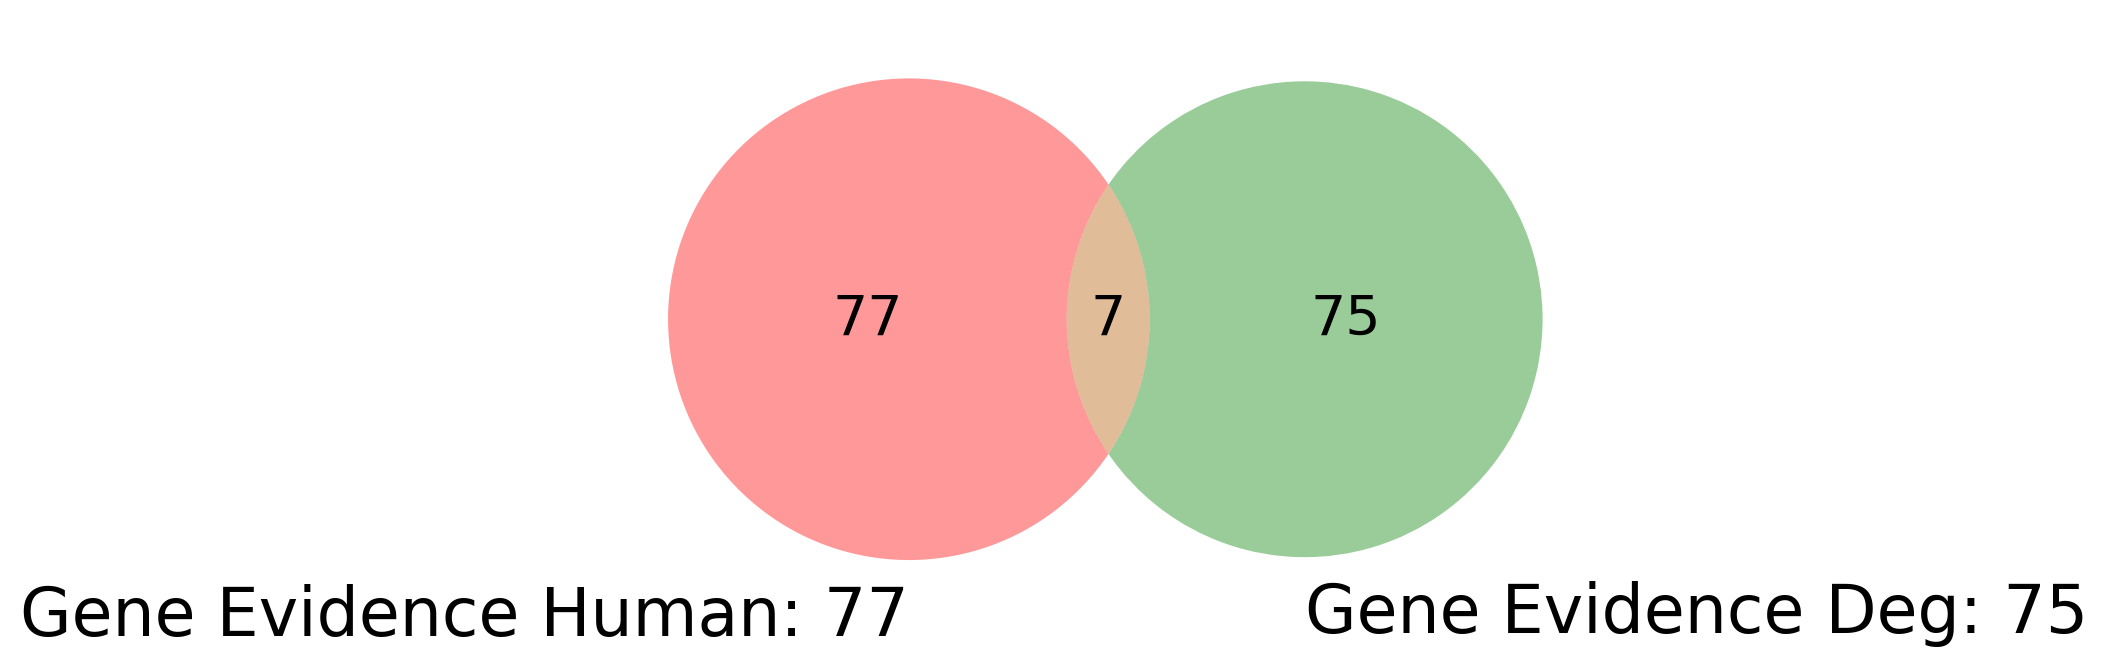

In [24]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, f'Gene Evidence Human: {left}', f'Gene Evidence Deg: {right}')

## Global Celltype Comparison

In [25]:
def get_standard_labels(labels):
    """
    Returns the standardized labels of cell type labels using a global map
    """

    with open('cell_type_label_map.json', 'r') as file:
        map_dict = json.load(file)
    
        for label in labels:
            standard_val = label
            for standard_label, options in map_dict.items():
                if label in options or label == standard_label:
                    standard_val = standard_label
            labels[labels == label] = standard_val
    return labels


In [26]:
feature = "cell_type_label" # eventually change this to comparing based on a map we can create

first = derived_human_ev[feature].str.strip().str.upper().unique()
first = get_standard_labels(first)
second = deg_ev[feature].str.strip().str.upper().unique()
second = get_standard_labels(second)

left  = set_diff(first, second)
itx   = set_itx(first, second)
right = set_diff(second, first)
itx_vals = set_itx_vals(first, second)

In [27]:
print(set_diff_vals(second, first))
print(set_diff_vals(first, second))
print(itx_vals)

['B CELL' 'MYELOID-LIKE CELLS']
['ILCP-LIKE CELLS (INNATE LYMPHOID PRECURSOR LIKE CELLS)'
 'IMMATURE NATURAL KILLER (INK) CELLS' 'IMS (INFLAMMATORY MACROPHAGES)'
 'INFLAMMATORY MACROPHAGES' 'INNATE LYMPHOID CELLS'
 'INNATE LYMPHOID PRECURSOR CELLS' 'LIPID-ASSOCIATED MACROPHAGES'
 'MONOCYTE' 'NEUTROPHIL' 'T CELL'
 'TISSUE RESIDENT NATURAL KILLER (TRNK) CELLS']
['CONVENTIONAL TYPE 1 DENDRITIC CELLS'
 'CONVENTIONAL TYPE 2 DENDRITIC CELLS' 'ENDOTHELIAL'
 'MATURE NATURAL KILLER CELLS' 'NATURAL KILLER LIKE CELLS'
 'NONCLASSIC MONOCYTES' 'PERIVASCULAR MACROPHAGES' 'PREADIPOCYTE'
 'SMOOTH MUSCLE CELLS']


22 9 3 ['CONVENTIONAL TYPE 1 DENDRITIC CELLS'
 'CONVENTIONAL TYPE 2 DENDRITIC CELLS' 'ENDOTHELIAL'
 'MATURE NATURAL KILLER CELLS' 'NATURAL KILLER LIKE CELLS'
 'NONCLASSIC MONOCYTES' 'PERIVASCULAR MACROPHAGES' 'PREADIPOCYTE'
 'SMOOTH MUSCLE CELLS']


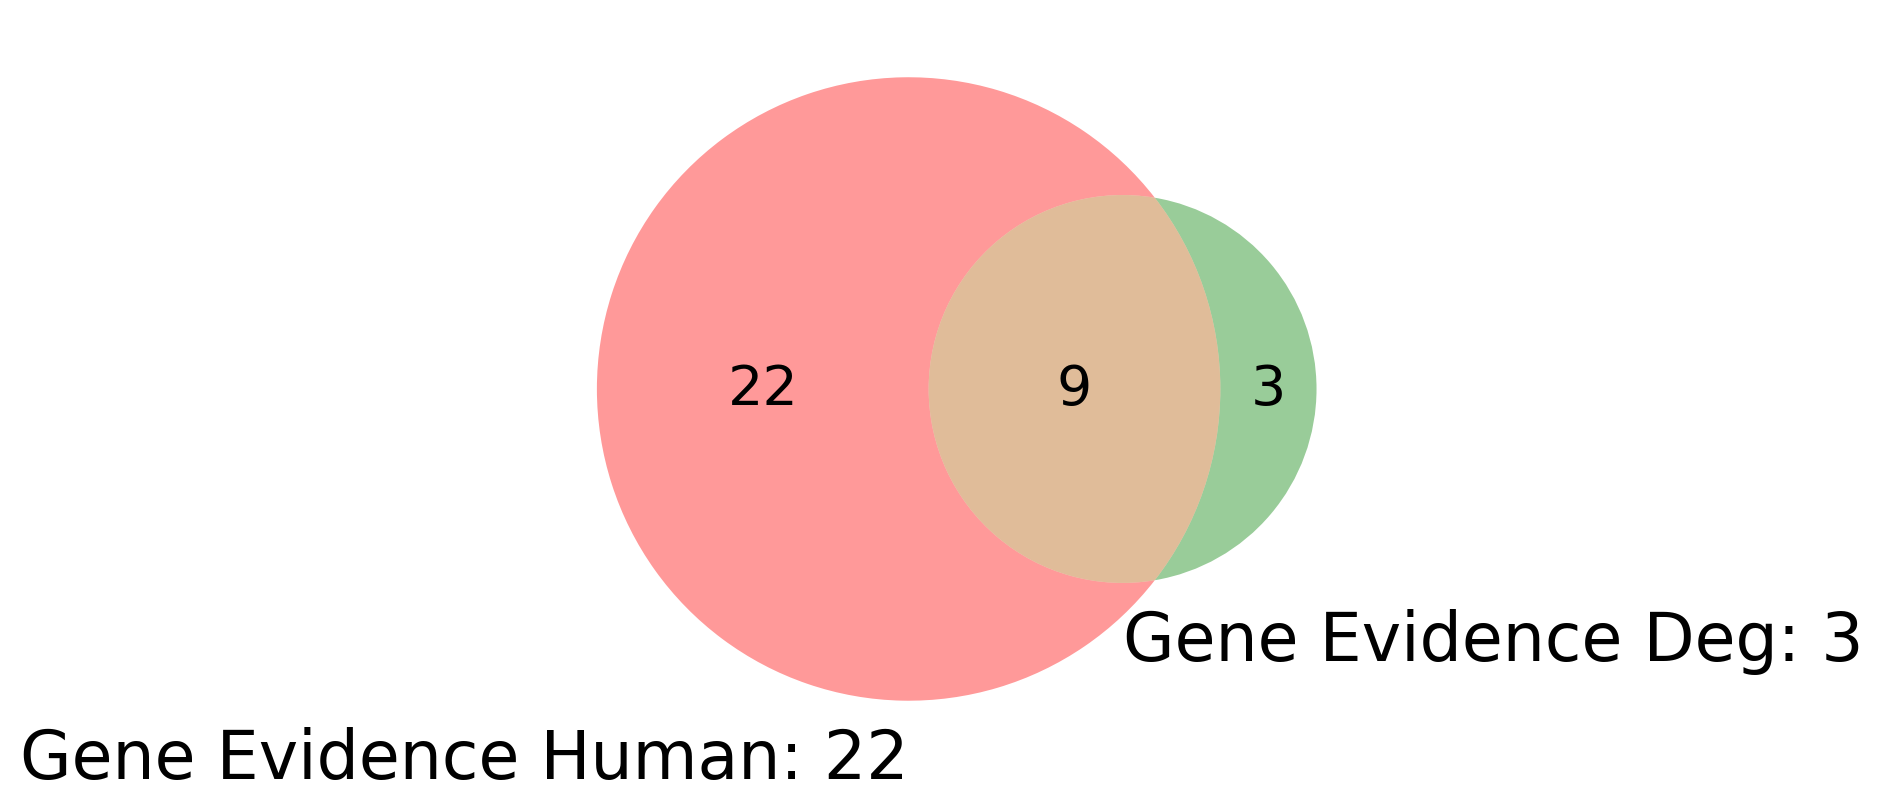

In [28]:
print(left, itx, right, itx_vals)
create_venn(left, right, itx, f'Gene Evidence Human: {left}', f'Gene Evidence Deg: {right}')

## Set Difference + Intersection of Gene Expression Between All Cells in Evidence Deg and Evidence Human

In [29]:
def make_3d_matrix(human_fn, deg_fn):
    """
    Finds similarites in gene expression between all cells mentioned in evidence deg and evidence human and returns a 3D matrix describing the left difference, intersection, and right difference in gene expression.

    Returns:
        pd.DataFrame: the 3D matrix describing set difference and intersection in gene expression
    """

    human_ev = load_human_evidence(human_fn) # gets only the derived part of evidence.json in evidence_human
    deg_ev = load_deg_evidence(deg_fn) 

    feature = "cell_type_label"

    # x axis is human evidence and y axis is deg evidence

    x_labels = sorted(human_ev[feature].unique())
    y_labels = sorted(deg_ev[feature].unique())

    result_df = pd.DataFrame(index = x_labels, columns=y_labels, dtype=object)

    for x in x_labels:
        for y in y_labels:
            genes1 = set(human_ev[human_ev[feature] == x]['gene_id'])
            genes2 = set(deg_ev[deg_ev[feature] == y]['gene_id'])

            left_diff = genes1 - genes2
            intersection = genes1 & genes2
            right_diff = genes2 - genes1

            result_df.loc[x,y] = [left_diff, intersection, right_diff]

    return result_df

In [30]:
matrix = make_3d_matrix(fn_human, fn_deg)

matrix

,APC,B cell,Endothelial,Myeloid-like,NK-like,PVM,Preadipocyte,Smooth muscle,cDC1,cDC2B,mNK,ncMo
APCs (adipocyte precursor cells),"[{ENSG00000184371, ENSG00000125378, ENST000007...","[{ENSG00000184371, ENSG00000125378, ENST000007...","[{ENSG00000184371, ENSG00000125378, ENST000007...","[{ENSG00000184371, ENSG00000125378, ENST000007...","[{ENSG00000184371, ENSG00000125378, ENST000007...","[{ENSG00000184371, ENSG00000125378, ENST000007...","[{ENSG00000184371, ENSG00000125378, ENST000007...","[{ENSG00000184371, ENSG00000125378, ENST000007...","[{ENSG00000184371, ENSG00000125378, ENST000007...","[{ENSG00000184371, ENSG00000125378, ENST000007...","[{ENSG00000184371, ENSG00000125378, ENST000007...","[{ENSG00000184371, ENSG00000125378, ENST000007..."
Endos (endothelial cells),"[{ENSG00000078401, ENSG00000107562}, {}, {ENSG...","[{ENSG00000078401, ENSG00000107562}, {}, {ENSG...","[{ENSG00000078401, ENSG00000107562}, {}, {ENSG...","[{ENSG00000078401, ENSG00000107562}, {}, {ENSG...","[{ENSG00000078401, ENSG00000107562}, {}, {ENSG...","[{ENSG00000078401, ENSG00000107562}, {}, {ENSG...","[{ENSG00000078401}, {ENSG00000107562}, {ENSG00...","[{ENSG00000078401, ENSG00000107562}, {}, {ENSG...","[{ENSG00000078401, ENSG00000107562}, {}, {ENSG...","[{ENSG00000078401, ENSG00000107562}, {}, {ENSG...","[{ENSG00000078401, ENSG00000107562}, {}, {ENSG...","[{ENSG00000078401, ENSG00000107562}, {}, {ENSG..."
ILC1s (type 1 innate lymphoid cells),"[{ENSG00000107485, ENSG00000157404, ENSG000001...","[{ENSG00000107485, ENSG00000157404, ENSG000001...","[{ENSG00000107485, ENSG00000157404, ENSG000001...","[{ENSG00000107485, ENSG00000157404, ENSG000001...","[{ENSG00000107485, ENSG00000157404, ENSG000001...","[{ENSG00000107485, ENSG00000157404, ENSG000001...","[{ENSG00000107485, ENSG00000157404, ENSG000001...","[{ENSG00000107485, ENSG00000157404, ENSG000001...","[{ENSG00000107485, ENSG00000157404, ENSG000001...","[{ENSG00000107485, ENSG00000157404, ENSG000001...","[{ENSG00000107485, ENSG00000157404, ENSG000001...","[{ENSG00000107485, ENSG00000157404, ENSG000001..."
ILC2s (type 2 innate lymphoid cells),"[{ENSG00000157404, ENSG00000115602, ENSG000001...","[{ENSG00000157404, ENSG00000115602, ENSG000001...","[{ENSG00000157404, ENSG00000115602, ENSG000001...","[{ENSG00000157404, ENSG00000115602, ENSG000001...","[{ENSG00000157404, ENSG00000115602, ENSG000001...","[{ENSG00000157404, ENSG00000115602, ENSG000001...","[{ENSG00000157404, ENSG00000115602, ENSG000001...","[{ENSG00000157404, ENSG00000115602, ENSG000001...","[{ENSG00000157404, ENSG00000115602, ENSG000001...","[{ENSG00000157404, ENSG00000115602, ENSG000001...","[{ENSG00000157404, ENSG00000115602, ENSG000001...","[{ENSG00000157404, ENSG00000115602, ENSG000001..."
ILC3s (type 3 innate lymphoid cells),"[{ENSG00000157404, ENSG00000128342, ENSG000001...","[{ENSG00000157404, ENSG00000128342, ENSG000001...","[{ENSG00000157404, ENSG00000128342, ENSG000001...","[{ENSG00000157404, ENSG00000128342, ENSG000001...","[{ENSG00000157404, ENSG00000128342, ENSG000001...","[{ENSG00000157404, ENSG00000128342, ENSG000001...","[{ENSG00000157404, ENSG00000128342, ENSG000001...","[{ENSG00000157404, ENSG00000128342, ENSG000001...","[{ENSG00000157404, ENSG00000128342, ENSG000001...","[{ENSG00000157404, ENSG00000128342, ENSG000001...","[{ENSG00000157404, ENSG00000128342, ENSG000001...","[{ENSG00000157404, ENSG00000128342, ENSG000001..."
ILCP-like cells (innate lymphoid precursor like cells),"[{ENSG00000157404, ENSG00000115594, ENSG000001...","[{ENSG00000157404, ENSG00000115594, ENSG000001...","[{ENSG00000157404, ENSG00000115594, ENSG000001...","[{ENSG00000157404, ENSG00000115594, ENSG000001...","[{ENSG00000157404, ENSG00000115594, ENSG000001...","[{ENSG00000157404, ENSG00000115594, ENSG000001...","[{ENSG00000157404, ENSG00000115594, ENSG000001...","[{ENSG00000157404, ENSG00000115594, ENSG000001...","[{ENSG00000157404, ENSG00000115594, ENSG000001...","[{ENSG00000157404, ENSG00000115594, ENSG000001...","[{ENSG00000157404, ENSG00000115594, EN

## Find Cells with Similar Expression

In [31]:
def find_similar_cells():
    """
    Goes through the matrix and counts the number of intersected genes to be able to easily identify similar cells

    Returns:
        pd.DataFrame: the 3D matrix describing the count in gene expression intersection
    """
    
    intersection_df = matrix.copy()
    for index in matrix.index:
        for value in matrix.columns:
            intersection = matrix.loc[index, value][1]

            count = len(intersection)

            intersection_df.loc[index, value] = count if count > 0 else None
    
    return intersection_df


In [32]:
cell_similarity_matrix = find_similar_cells()

cell_similarity_matrix

,APC,B cell,Endothelial,Myeloid-like,NK-like,PVM,Preadipocyte,Smooth muscle,cDC1,cDC2B,mNK,ncMo
APCs (adipocyte precursor cells),None,None,None,None,None,None,1,None,None,None,None,None
Endos (endothelial cells),None,None,None,None,None,None,1,None,None,None,None,None
ILC1s (type 1 innate lymphoid cells),None,None,None,None,None,None,None,None,None,None,None,None
ILC2s (type 2 innate lymphoid cells),None,None,None,None,None,None,None,None,None,None,None,None
ILC3s (type 3 innate lymphoid cells),None,None,None,None,None,None,None,None,None,None,None,None
ILCP-like cells (innate lymphoid precursor like cells),None,None,None,None,None,None,None,None,None,None,None,None
ILCPs (innate lymphoid precursor cells),None,None,None,None,None,None,None,None,None,None,None,None
IMs (inflammatory macrophages),None,None,None,None,None,None,None,None,None,None,None,None
LAMs (lipid-associated macrophages),None,None,None,None,None,None,None,None,None,None,None,None
Mo-1s (monocyte 1),None,None,None,None,None,None,None,None,None,1,None,None


In [33]:
def get_similar_cells():
    result = []
    for index in cell_similarity_matrix.index:
        for value in cell_similarity_matrix.columns:
            if cell_similarity_matrix.loc[index, value]:
                result.append([index, value])
    return result


In [34]:
get_similar_cells()

[['APCs (adipocyte precursor cells)', 'Preadipocyte'],
 ['Endos (endothelial cells)', 'Preadipocyte'],
 ['Mo-1s (monocyte 1)', 'cDC2B'],
 ['Mo-2s (monocyte 2)', 'Myeloid-like'],
 ['Neu (neutrophils)', 'Myeloid-like'],
 ['PVMs (perivascular macrophages)', 'PVM'],
 ['WAT cDC2s (white adipose tissue conventional type 2 dendritic cells)',
  'PVM'],
 ['WAT cDC2s (white adipose tissue conventional type 2 dendritic cells)',
  'cDC2B'],
 ['conventional type 2 dendritic cells subset B (cDC2Bs)', 'PVM'],
 ['conventional type 2 dendritic cells subset B (cDC2Bs)', 'cDC2B'],
 ['human WAT (white adipose tissue) neutrophils', 'Myeloid-like'],
 ['inflammatory macrophages', 'Myeloid-like'],
 ['pADs (preadipocytes)', 'Preadipocyte']]